<a href="https://colab.research.google.com/github/CristopherWallau/PythonDataScience/blob/main/Projeto_Evcomx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pré-processamento**


**Importação**

In [98]:
import pandas as pd

In [99]:
df = pd.read_csv('dados_fundo_do_amanha_evcomx.csv', sep=';')

In [100]:
pd.set_option('display.max_columns', 22)
df.head(n=10)

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
1,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1652,1672,1543.0,1555.0
2,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1650,1670,1543.0,1555.0
3,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1655,1672,1543.0,1555.0
4,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
5,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1651,1672,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
7,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1681,1678,1543.0,1547.0
8,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1680,1678,1543.0,1547.0
9,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1677,1678,1543.0,1547.0


**Tamanho**

In [101]:
df.shape

(48658, 22)

**Tipo**

In [102]:
df.dtypes

corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
velocidadeobjetivada     float64
velocidadereal           float64
sugestaomodelolegado       int64
temperaturasaidafp         int64
temperaturaobjetivada    float64
temperaturamediareal     float64
dtype: object

**Percentual de dados faltantes por coluna**



In [103]:
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().sum() / len(df['corrida'])) * 100
print(faltantes_percentual)

corrida                  0.000000
secao                    0.000000
acoatual                 0.000000
qualidade                0.000000
al_min                   0.000000
c_min                    0.000000
c_max                    0.000000
n_min                    0.000000
s_min                    0.000000
sequencia                0.000000
sequenciatotal           0.000000
panela                   0.000000
vidapanela               0.000000
tempociclo               0.000000
tempovacuototal          0.000000
temperaturaliquidus      0.000000
velocidadeobjetivada     0.000000
velocidadereal           0.000000
sugestaomodelolegado     0.000000
temperaturasaidafp       0.000000
temperaturaobjetivada    0.000000
temperaturamediareal     0.024662
dtype: float64


**Exclusão das linhas com valores nulos**

In [104]:
#Como a porcentagem de dados faltantes é irrelevante(menos de 5%) apenas descartamos os valores NAN e/ou nulos

df = df.dropna()

**Removendo colunas duplicadas**

In [105]:
#Removemos as colunas duplicadas baseado na coluna corrida e mantendo a mais recente conforme instruido

df = df.drop_duplicates(subset=['corrida'], keep='first')
df.shape

(7482, 22)

In [106]:
df.head()

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


# Comportamento de Tsaidafp

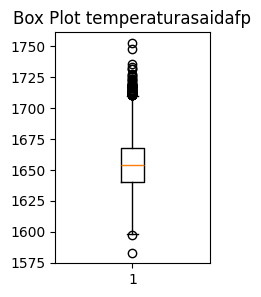

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturasaidafp)
plt.title("Box Plot temperaturasaidafp")
plt.show()

# Comportamento de Temperaturamediareal

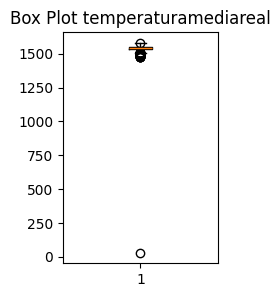

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturamediareal)
plt.title("Box Plot temperaturamediareal")
plt.show()

# Retirando outlier absurdo e plotando novamente

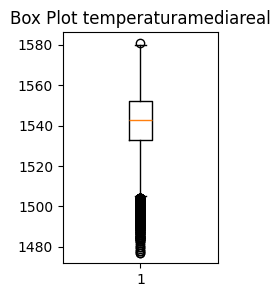

In [109]:
df = df[(df.temperaturamediareal > 500)]
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturamediareal)
plt.title("Box Plot temperaturamediareal")
plt.show()

# Comportamento de Temperaturaobjetivada

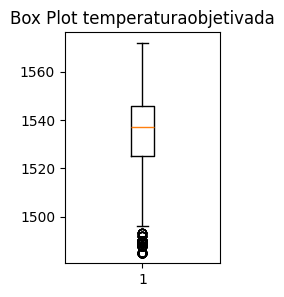

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturaobjetivada)
plt.title("Box Plot temperaturaobjetivada")
plt.show()

# Comportamento de VidaPanela

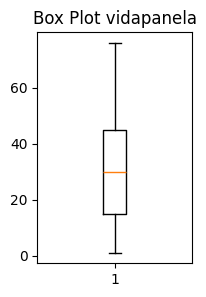

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 3))
plt.boxplot(df.vidapanela)
plt.title("Box Plot vidapanela")
plt.show()

# Comportamento de Secao

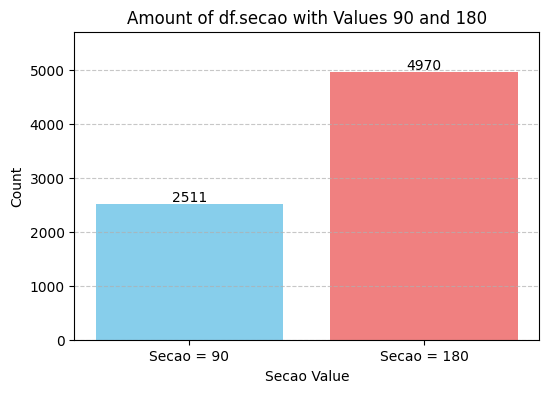

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    # Calculate the counts for the desired values
    counts = df['secao'].value_counts()

    # Extract the counts for 90 and 180, defaulting to 0 if they don't exist
    count_90 = counts.get(90)
    count_180 = counts.get(180)

    # Prepare data for plotting
    labels = ['Secao = 90', 'Secao = 180']
    amounts = [count_90, count_180]

    # Create the bar chart
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, amounts, color=['skyblue', 'lightcoral'])

    # Add the count values on top of the bars for clarity
    for bar in bars:
        yval = bar.get_height()
        # Only show text if count > 0
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom')

    plt.title('Amount of df.secao with Values 90 and 180')
    plt.xlabel('Secao Value')
    plt.ylabel('Count')
    # Set y limit slightly higher than max count
    plt.ylim(0, max(amounts) * 1.15 if amounts else 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show() 

except Exception as e:
    print(f"An error occurred: {e}")
    plt.show()
    # Clear the figure
    plt.clf()
    

In [122]:
count_90.describe()

AttributeError: 'numpy.int64' object has no attribute 'describe'

In [124]:
# Calculate mean temperaturamediareal for secao 90 and 180
mean_90 = df.loc[df['secao'] == 90, 'temperaturamediareal'].mean()
mean_180 = df.loc[df['secao'] == 180, 'temperaturamediareal'].mean()

df.groupby('secao')['temperaturamediareal'].describe()

,count,mean,std,min,25%,50%,75%,max
secao,,,,,,,,
90.0,2511.0,1544.054958,12.761721,1486.0,1536.0,1544.0,1553.0,1581.0
180.0,4970.0,1539.436821,17.010341,1477.0,1531.0,1542.0,1552.0,1578.0


Removi a variavel secao devido a analise feita acima

In [125]:
df = df.drop(columns=['secao'])

Tsaidafp x Tmediareal

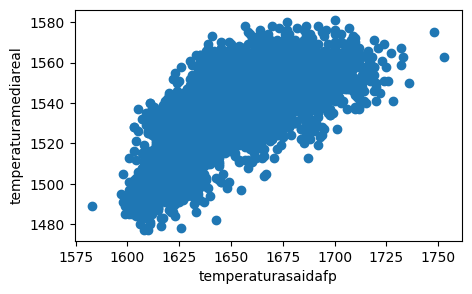

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.scatter(df.temperaturasaidafp, df.temperaturamediareal)
plt.xlabel('temperaturasaidafp')
plt.ylabel('temperaturamediareal')
plt.show()

Removendo os valores muito baixos de sugestaomodelolegado

In [ ]:
df = df[df['sugestaomodelolegado'] >= 200].copy()

Tmodelolegado x Tmediareal

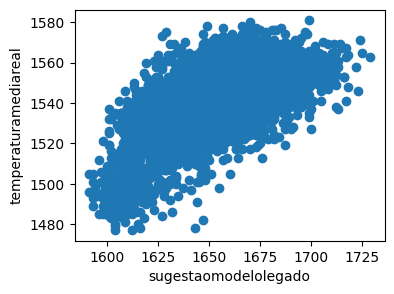

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.scatter(df_filtered.sugestaomodelolegado, df_filtered.temperaturamediareal)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturamediareal')
plt.show()
#o gráfico mostra que o modelo legado está muito disperso em relação a tmediareal

Tmodelolegado x Tobjetivada

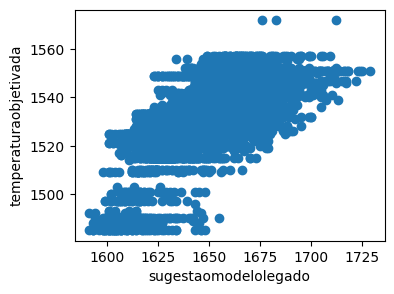

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.scatter(df_filtered.sugestaomodelolegado, df_filtered.temperaturaobjetivada)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturaobjetivada')
plt.show()
#o gráfico mostra que o modelo legado está muito disparso em relação a temperatura objetivada

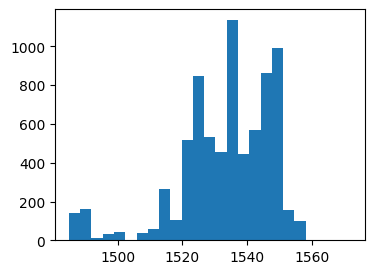

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(df['temperaturaobjetivada'], bins=25)
plt.show()

In [118]:
#A variável corrida só serviu para limpar valores duplicados, não tem mais utilidade, deve ser removida

df = df.drop(columns=['corrida'])
df.shape

(7481, 21)

# **Análise exploratória**

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
valores_unicos = df.nunique()

print(valores_unicos)

secao                       2
acoatual                 3503
qualidade                 253
al_min                      4
c_min                     121
c_max                     126
n_min                       3
s_min                      29
sequencia                  11
sequenciatotal             11
panela                     12
vidapanela                 76
tempociclo               3902
tempovacuototal            24
temperaturaliquidus        49
velocidadeobjetivada       13
velocidadereal            115
sugestaomodelolegado      134
temperaturasaidafp        138
temperaturaobjetivada      59
temperaturamediareal      105
dtype: int64


**Comportamento da variável target**

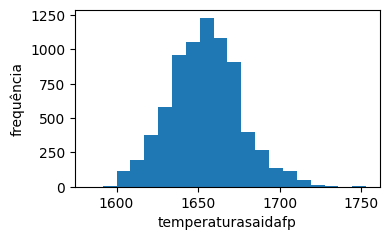

In [ ]:
plt.figure(figsize=(4,2.5))

plt.hist(df['temperaturasaidafp'], bins=20)
plt.xlabel('temperaturasaidafp')
plt.ylabel('frequência')
plt.tight_layout()
plt.show()

In [ ]:
media = df['temperaturasaidafp'].mean()
mediana = df['temperaturasaidafp'].median()

print(f"Média: {media}")
print(f"Mediana: {mediana}")

Média: 1653.9966586474204
Mediana: 1654.0


**Comportamento secao x target**

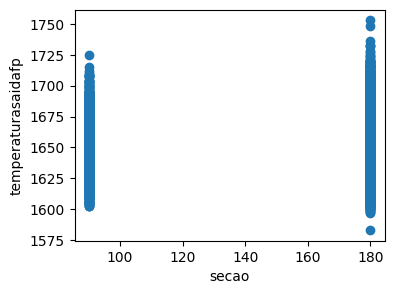

In [ ]:
plt.figure(figsize=(4, 3))

plt.scatter(df['secao'], df['temperaturasaidafp'])
plt.xlabel('secao')
plt.ylabel('temperaturasaidafp')
plt.show()

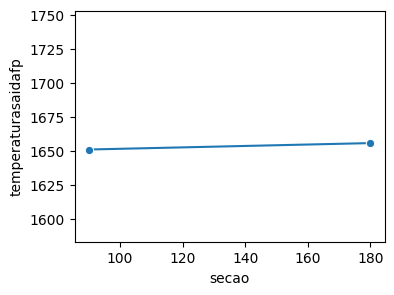

In [ ]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='secao', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('secao')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.show()

**Comportamento al_min x target**

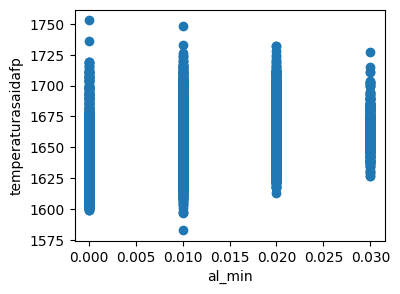

In [ ]:
plt.figure(figsize=(4, 3))

plt.scatter(df['al_min'], df['temperaturasaidafp'])
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.show()

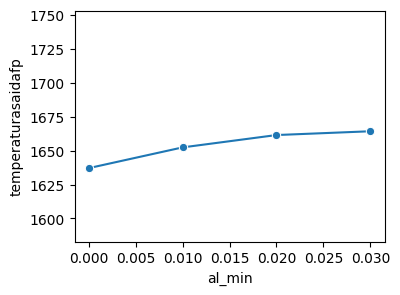

In [ ]:
plt.figure(figsize=(4, 3))

sns.lineplot(data=df, x='al_min', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.show()

# **Avaliação de desempenho do modelo legado**

In [ ]:
df['usage'] = df.apply(
    lambda row: 'usou' if row['sugestaomodelolegado']== row['temperaturasaidafp']
    else 'Naousou',axis=1)
display(df[['temperaturasaidafp', 'temperaturamediareal', 'usage']].head())

In [ ]:
# Calculate the percentage of 'usou' and 'Naousou' in the 'usage' column
usage_percentage = df['usage'].value_counts(normalize=True) * 100

# Print the percentages
print("Porcentagem de 'usou' e 'Naousou':")
print(usage_percentage)

In [ ]:
df['usage'] = df.apply(
    lambda row: 'usou' if row['sugestaomodelolegado']-row['temperaturasaidafp'] >=-1
    and row['sugestaomodelolegado'] - row['temperaturasaidafp'] <=1
    else 'Naousou',axis=1)
display(df[['temperaturasaidafp', 'temperaturamediareal', 'usage']].head())

In [ ]:
# Calculate the percentage of 'usou' and 'Naousou' in the 'usage' column
usage_percentage = df['usage'].value_counts(normalize=True) * 100

# Print the percentages
print("Porcentagem de 'usou' e 'Naousou':")
print(usage_percentage)

In [ ]:
df['diferenca'] = df['sugestaomodelolegado'] - df['temperaturasaidafp']
display(df[['sugestaomodelolegado', 'temperaturasaidafp', 'diferenca']].head())

In [ ]:
df['nova_temperatura'] = df['diferenca'] + df['temperaturamediareal']
display(df[['diferenca', 'temperaturamediareal', 'nova_temperatura']].head())

In [ ]:
def check_temperature_range(row):
    nova_temperatura = row['nova_temperatura']
    temperatura_objetivada = row['temperaturaobjetivada']
    if (nova_temperatura >= temperatura_objetivada - 5) and (nova_temperatura <= temperatura_objetivada + 10):
        return 'acerto'
    elif nova_temperatura < (temperatura_objetivada - 5):
        return 'erro para baixo'
    else: # nova_temperatura > (temperatura_objetivada + 10)
        return 'erro para cima'

df['flag_nova_temperatura'] = df.apply(check_temperature_range, axis=1)
display(df[['nova_temperatura', 'temperaturaobjetivada', 'flag_nova_temperatura']].head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'acerto' and 'erro'
flag_counts = df['flag_nova_temperatura'].value_counts(normalize=True) * 100

# Create a bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette=['green', 'red', 'blue'], hue=flag_counts.index, legend=False)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros do Modelo')
plt.ylim(0, 100)
plt.show()

In [ ]:
df_copia = df.copy()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the original temperaturamediareal is within the desired range of temperaturaobjetivada
is_within_range_original = (df['temperaturamediareal'] >= df['temperaturaobjetivada'] - 5) & \
                           (df['temperaturamediareal'] <= df['temperaturaobjetivada'] + 10)

# Create a new column to flag these cases
df['flag_original_range'] = is_within_range_original.apply(lambda x: 'acerto' if x else 'erro')

# Calculate the percentage of 'acerto' and 'erro' for the original data
flag_counts_original = df['flag_original_range'].value_counts(normalize=True) * 100

# Create a bar plot for the original data
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts_original.index, y=flag_counts_original.values, palette=['green', 'red'], hue=flag_counts_original.index, legend=False)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros (Dados Originais)')
plt.ylim(0, 100)
plt.show()

In [ ]:
# Filter the DataFrame to remove rows where 'flag_original_range' is 'erro'
df = df[df['flag_original_range'] != 'erro'].copy()

print("Shape of the filtered DataFrame:", df.shape)

# **Seleção de variáveis**

In [ ]:
df.vidapanela.value_counts()

In [ ]:
df.vidapanela.hist()

In [ ]:
import matplotlib.pyplot as plt
df_teste = df[df.temperaturasaidafp > 500]
plt.figure(figsize=(10, 6))
plt.scatter(df_teste['vidapanela'], df_teste['temperaturasaidafp'], alpha=0.5)
plt.title('Relação entre Vida da Panela e Temperatura Saidafp')
plt.xlabel('Vida da Panela')
plt.ylabel('Temperatura Saidafp')
plt.show()

In [ ]:
df.panela.value_counts()

In [ ]:
df.panela.hist()

In [ ]:
import matplotlib.pyplot as plt
df_teste = df[df.temperaturasaidafp > 500]
plt.figure(figsize=(10, 6))
plt.scatter(df_teste['panela'], df_teste['temperaturasaidafp'], alpha=0.5)
plt.title('Relação entre Panela e Temperatura Saidafp')
plt.xlabel(' Panela')
plt.ylabel('Temperatura Saidafp')
plt.show()

**Correlação**

In [ ]:
df.head()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

colunas_objeto = ['acoqualidade','usage','diferenca','flag_nova_temperatura','flag_original_range','velocidadereal','temperaturamediareal','sugestaomodelolegado']
df_sem_objeto = df.drop(columns=colunas_objeto)

corr = df_sem_objeto.corr(numeric_only=True,method='spearman')

plt.figure(figsize=(12,12))
ax = sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, fmt=".2f")

# Pegar o tamanho da matriz
n = corr.shape[0]

# Plotar uma diagonal verde (usando scatter)
ax.scatter(
    x=np.arange(0.5, n),  # posições no eixo x
    y=np.arange(0.5, n),  # posições no eixo y
    c="green", s=200, marker="s"  # quadrados verdes grandes
)

plt.show()

In [ ]:
corr.corr(method='spearman')


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
# Drop non-numeric columns and the target variable for VIF calculation
# Assuming 'temperaturasaidafp' is the target variable
df_numeric = df.select_dtypes(include=['number']).drop(columns=['temperaturasaidafp', 'nova_temperatura', 'diferenca','temperaturamediareal','sugestaomodelolegado',
                                                                'velocidadereal','c_min','c_max'])
df_numeric = add_constant(df_numeric)
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

# Display the VIF values
display(vif_data.sort_values(by='VIF', ascending=False))

# Juntando Variaveis correlacionadas

Abaixo juntaremos as variáveis c_min e c_max usando a média das 2 baseado no heatmap plotado na seção acima que mostra que elas sao extremamente correlacioandas

In [ ]:
df['c_mean'] = (df['c_min'] + df['c_max']) / 2
df = df.drop(columns=['c_min', 'c_max'])
display(df.head())

#Excluindo variáveis

# **Modelo**

Separando a variável alvo (y) e as features (x)

In [ ]:
# To display the head of the dataframe with more columns, use display() and set pandas options
import pandas as pd

pd.set_option('display.max_columns', 24)
display(df.head())

#Mudando acoqualidade para variaveis não categóricas


In [ ]:
!pip install optbinning

In [ ]:
from optbinning import ContinuousOptimalBinning

optb = ContinuousOptimalBinning(name='Extracurricular Activities',dtype = 'categorical')
optb.fit(df['acoqualidade'],df['temperaturasaidafp'])

In [ ]:
len(df['acoqualidade'].unique())

In [ ]:
optb.binning_table.build()

In [ ]:
import numpy as np

# Get the binning table
binning_table = optb.binning_table.build()

# Create a new column for WoE values, initialized to NaN
df['acoqualidade_woe_optb'] = np.nan
df_copia['acoqualidade_woe_optb'] = np.nan
# Iterate through the bins and assign the WoE value to the corresponding rows
for i in range(16):
    bin_values = binning_table.Bin[i]
    woe_value = binning_table.WoE[i]

    # Handle the 'Special' and 'Missing' bins if necessary (optional, depending on your data)
    # Check if bin_values is the string 'Special' or 'Missing'
    if isinstance(bin_values, str) and (bin_values == 'Special' or bin_values == 'Missing'):
        # You might want to assign a specific WoE value or handle these cases differently
        # For now, we'll skip them as they have 0 count in your current output
        continue
    else:
        # For regular bins, check if the acoqualidade value is in the list of bin_values
        # Ensure bin_values is treated as a list or array for checking membership
        if isinstance(bin_values, (list, np.ndarray)):
             df.loc[df['acoqualidade'].isin(bin_values), 'acoqualidade_woe_optb'] = woe_value
             df_copia.loc[df_copia['acoqualidade'].isin(bin_values), 'acoqualidade_woe_optb'] = woe_value
        else:
             # Handle cases where bin_values might be a single value (less common for categorical)
             df.loc[df['acoqualidade'] == bin_values, 'acoqualidade_woe_optb'] = woe_value
             df_copia.loc[df_copia['acoqualidade'] == bin_values, 'acoqualidade_woe_optb'] = woe_value


# Display the head of the dataframe with the new WoE column
display(df[['acoqualidade', 'acoqualidade_woe_optb']].head())

## Train and evaluate model

### Subtask:
Train the machine learning model (Random Forest Regressor in cell `4hpQrgAc6oYH`) using the data with the WoE transformed feature and evaluate its performance.


In [ ]:
# Ensure df_binario is updated with the latest columns including 'c_mean' and 'acoqualidade_woe'
# Recreate df_binario by dropping original categorical and min/max columns from df,
# then concatenating with the one-hot encoded columns and the new c_mean column.
variavel_alvo = 'temperaturasaidafp'
# Identify columns to drop from the main dataframe for the numerical part of X
# Only include columns that are definitely in df and should not be features
columns_to_drop_from_df = [
    'acoqualidade', # Original categorical column
    'target_binary', # Binary target (if not using it)
    variavel_alvo,  # Target variable
    'temperaturamediareal', # As per previous logic to exclude this from features for predicting temperaturasaidafp
    'velocidadereal', # As per previous logic to exclude this from features
    'flag_nova_temperatura', # Flags are results, not features for prediction (assuming it exists)
    'flag_original_range', # Flags are results, not features for prediction (assuming it exists)
    'usage', # As per previous logic to exclude this from features (assuming it exists)
    'sugestaomodelolegado' # As per previous logic to exclude this from features
]

# Filter columns_to_drop_from_df to only include those present in df.columns
columns_to_drop_from_df = [col for col in columns_to_drop_from_df if col in df.columns]


# The 'acoqualidade_woe_alg' column is now the numerical representation of the categorical feature using the user's WoE algorithm.
# We will create the feature set X directly from df, selecting the relevant columns and dropping those not needed.
# Exclude the original categorical columns, the target, legacy predictions, and the flags, and include the new WoE column.
X = df.drop(columns=columns_to_drop_from_df, axis=1)

# Define the target variable
y = df[[variavel_alvo]]

# Display the shapes of X and y to verify
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

display(X.head())
display(y.head())

In [ ]:
sorted(list(X.columns))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor model
novo_modelo = RandomForestRegressor(n_estimators=100, random_state=42,max_depth = 5)
novo_modelo.fit(x_train, y_train)

print("Model training complete.")

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Pega a primeira árvore do Random Forest
arvore = novo_modelo.estimators_[0]

# Plota a árvore
plt.figure(figsize=(20, 10))
plot_tree(arvore, feature_names=X.columns, filled=True, max_depth=4, fontsize=10)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Obter importâncias das features
importancias = novo_modelo.feature_importances_

# Criar um DataFrame para visualizar melhor
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

# Exibir tabela de importâncias
print(feature_importance_df)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # inverter eixo para mostrar maior importância no topo
plt.title('Importância das Features (RandomForest)')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred_novo = novo_modelo.predict(x_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_novo)
mse = mean_squared_error(y_test, y_pred_novo)
rmse = np.sqrt(mse)  # Calculate RMSE manually
r2 = r2_score(y_test, y_pred_novo)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
# --- Evaluate new model based on the -5 to +10 degree range from temperaturamediareal ---

temperaturamediareal_test = df.loc[x_test.index, 'temperaturamediareal']
temperaturaobjetivada_test = df.loc[x_test.index, 'temperaturaobjetivada']
temperaturasaidafp_test = df.loc[x_test.index,'temperaturasaidafp']

# Calculate the difference between predicted temperaturasaidafp and temperaturamediareal
difference_pred_media = y_pred_novo - temperaturasaidafp_test

# Calculate the new temperature by adding this difference to temperaturamediareal
nova_temperatura_pred = temperaturamediareal_test + difference_pred_media


# Check if the new calculated temperature is within the desired range of temperaturaobjetivada (-5 to +10)
# The range is [temperaturaobjetivada - 5, temperaturaobjetivada + 10]
is_within_range = (nova_temperatura_pred >= temperaturaobjetivada_test - 5) & \
                  (nova_temperatura_pred <= temperaturaobjetivada_test + 10)


# Calculate the percentage of predictions within the range
percentage_within_range = (is_within_range.sum() / len(y_test)) * 100

print("\n--- New Model Performance vs. Temperaturamediareal Range ---")
print(f"Percentage of predictions within -5 to +10 degrees of temperaturaobjetivada: {percentage_within_range:.2f}%")

In [ ]:
# Ensure df_binario is updated with the latest columns including 'c_mean' and 'acoqualidade_woe'
# Recreate df_binario by dropping original categorical and min/max columns from df,
# then concatenating with the one-hot encoded columns and the new c_mean column.
variavel_alvo = 'temperaturasaidafp'
# Identify columns to drop from the main dataframe for the numerical part of X
# Only include columns that are definitely in df and should not be features
columns_to_drop_from_df = [
    'acoqualidade', # Original categorical column
    'target_binary', # Binary target (if not using it)
    variavel_alvo,  # Target variable
    'temperaturamediareal', # As per previous logic to exclude this from features for predicting temperaturasaidafp
    'velocidadereal', # As per previous logic to exclude this from features
    'flag_nova_temperatura', # Flags are results, not features for prediction (assuming it exists)
    'usage', # As per previous logic to exclude this from features (assuming it exists)
    'sugestaomodelolegado' # As per previous logic to exclude this from features
]

# Filter columns_to_drop_from_df to only include those present in df.columns
columns_to_drop_from_df = [col for col in columns_to_drop_from_df if col in df.columns]


# The 'acoqualidade_woe_alg' column is now the numerical representation of the categorical feature using the user's WoE algorithm.
# We will create the feature set X directly from df, selecting the relevant columns and dropping those not needed.
# Exclude the original categorical columns, the target, legacy predictions, and the flags, and include the new WoE column.
X1 = df_copia.drop(columns=columns_to_drop_from_df, axis=1)

# Define the target variable
y1 = df_copia[[variavel_alvo]]

# Display the shapes of X and y to verify
print("Shape of X:", X1.shape)
print("Shape of y:", y1.shape)

display(X1.head())
display(y1.head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor model
novo_modelo = RandomForestRegressor(n_estimators=100, random_state=42,max_depth = 5)
novo_modelo.fit(x_train, y_train)

print("Model training complete.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Obter importâncias das features
importancias = novo_modelo.feature_importances_

# Criar um DataFrame para visualizar melhor
feature_importance_df = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

# Exibir tabela de importâncias
print(feature_importance_df)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # inverter eixo para mostrar maior importância no topo
plt.title('Importância das Features (RandomForest)')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred_novo = novo_modelo.predict(x_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_novo)
mse = mean_squared_error(y_test, y_pred_novo)
rmse = np.sqrt(mse)  # Calculate RMSE manually
r2 = r2_score(y_test, y_pred_novo)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
# --- Evaluate new model based on the -5 to +10 degree range from temperaturamediareal ---

temperaturamediareal_test = df_copia.loc[x_test.index, 'temperaturamediareal']
temperaturaobjetivada_test = df_copia.loc[x_test.index, 'temperaturaobjetivada']
temperaturasaidafp_test = df_copia.loc[x_test.index,'temperaturasaidafp']

# Calculate the difference between predicted temperaturasaidafp and temperaturamediareal
difference_pred_media = y_pred_novo - temperaturasaidafp_test

# Calculate the new temperature by adding this difference to temperaturamediareal
nova_temperatura_pred = temperaturamediareal_test + difference_pred_media


# Check if the new calculated temperature is within the desired range of temperaturaobjetivada (-5 to +10)
# The range is [temperaturaobjetivada - 5, temperaturaobjetivada + 10]
is_within_range = (nova_temperatura_pred >= temperaturaobjetivada_test - 5) & \
                  (nova_temperatura_pred <= temperaturaobjetivada_test + 10)


# Calculate the percentage of predictions within the range
percentage_within_range = (is_within_range.sum() / len(y_test)) * 100

print("\n--- New Model Performance vs. Temperaturamediareal Range ---")
print(f"Percentage of predictions within -5 to +10 degrees of temperaturaobjetivada: {percentage_within_range:.2f}%")